In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [58]:
customer_rfm = pd.read_csv("../data/processed/modeling_data.csv")

In [59]:
customer_rfm.shape

(62145, 6)

In [60]:
customer_rfm.head()

,customer_unique_id,recency,frequency,monetary,average_order_value,repeat_purchase
0,0000f46a3911fa3c0805444483337064,385.121493,1,86.22,86.22,0
1,0000f6ccb0745a6a4b88665a16c9f078,169.146053,1,43.62,43.62,0
2,0004aac84e0df4da2b147fca70cf8255,136.176597,1,196.89,196.89,0
3,00053a61a98854899e70ed204dd4bafe,30.530775,1,419.18,419.18,0
4,0005e1862207bf6ccc02e4228effd9a0,391.019306,1,150.12,150.12,0


In [61]:
customer_rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 62145 entries, 0 to 62144
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_unique_id   62145 non-null  str    
 1   recency              62145 non-null  float64
 2   frequency            62145 non-null  int64  
 3   monetary             62145 non-null  float64
 4   average_order_value  62145 non-null  float64
 5   repeat_purchase      62145 non-null  int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 2.8 MB


In [62]:
customer_rfm.isna().sum()

customer_unique_id     0
recency                0
frequency              0
monetary               0
average_order_value    0
repeat_purchase        0
dtype: int64

In [63]:
customer_rfm["repeat_purchase"].value_counts()

repeat_purchase
0    61544
1      601
Name: count, dtype: int64

## Defining X and y

In [64]:
model_features = ["recency", "frequency", "monetary", "average_order_value"]

X = customer_rfm[model_features].copy()
y = customer_rfm["repeat_purchase"].copy()

### X = information the model is allowed to use
repeat purchase cannot be in X(leakage)


### y = the answer we are trying to predict

In [65]:
y.value_counts()

repeat_purchase
0    61544
1      601
Name: count, dtype: int64

In [66]:
y.value_counts(normalize=True)

repeat_purchase
0    0.990329
1    0.009671
Name: proportion, dtype: float64

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, stratify = y, random_state = 42)

In [68]:
print("Training set:", X_train.shape)
print("\nTest set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTest target:")
print(y_test.value_counts())

Training set: (49716, 4)

Test set: (12429, 4)

Training target:
repeat_purchase
0    49235
1      481
Name: count, dtype: int64

Test target:
repeat_purchase
0    12309
1      120
Name: count, dtype: int64


# Building the First model : Logistic Regression

### StandardScaler > Logistic Regression > Class weight = balanced

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([

    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(class_weight = "balanced", random_state = 42))

])

model.fit(X_train,y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['recency','frequency','monetary','average_order_value']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### ``Class_weight=balanced`` tells logistic regression to give mroe importance to the minority class during training


In [70]:
y_pred = model.predict(X_test)

### Probabilities

tells how strongly the model believes a customer belongs tot he repeat purchase class

In [71]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [72]:
# calculating metrics

from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score, confusion_matrix

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

pr_auc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

conf_matrix = confusion_matrix(y_test, y_pred)

In [73]:
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Average Precision:", pr_auc)
print("ROC-AUC:", roc_auc)

print("\nConfusion Matrix:")
print(conf_matrix)

Precision: 0.013570145679505088
Recall: 0.5666666666666667
F1: 0.026505554472812318
Average Precision: 0.02181855013946516
ROC-AUC: 0.61763208492431

Confusion Matrix:
[[7366 4943]
 [  52   68]]


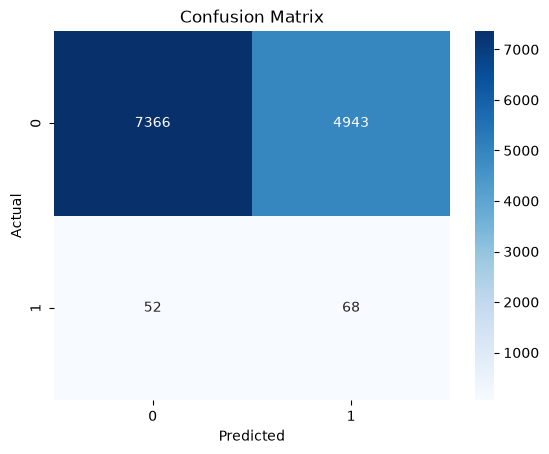

In [74]:
# inspect the matrix

sns.heatmap(conf_matrix, 
            annot = True,
            fmt = "d", 
            cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


### Why Threshold Analysis?

The Logistic Regression model produces a probability of repeat purchase for each customer, which is then converted into a binary prediction using a classification threshold.

 With only 0.97% of customers making a future repeat purchase, the default threshold of 0.50 resulted in a large number of false positives and very low precision. 
 
 Therefore, threshold analysis will evaluate different probability cutoffs and understand the trade-off between precision and recall.
 
helps determine whether a lower or higher threshold provides a more useful balance for identifying potential repeat purchasers.

In [75]:
thresholds = [0.50, 0.40, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01]

In [76]:
threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

In [77]:
threshold_results = pd.DataFrame(threshold_results)

threshold_results

,threshold,precision,recall,f1
0,0.50,0.013570,0.566667,0.026506
1,0.40,0.010035,0.975000,0.019866
2,0.30,0.009747,1.000000,0.019305
3,0.20,0.009678,1.000000,0.019171
4,0.10,0.009659,1.000000,0.019133
5,0.05,0.009655,1.000000,0.019125
6,0.02,0.009655,1.000000,0.019125
7,0.01,0.009655,1.000000,0.019125


### Threshold Analysis Findings

The threshold analysis showed that lowering the classification threshold substantially increased recall but resulted in very low precision. At the default threshold of 0.50, the model achieved 56.7% recall with 1.36% precision. Lowering the threshold to 0.40 increased recall to 97.5%, but precision decreased to approximately 1.00%. At thresholds of 0.30 and below, the model identified all repeat purchasers but precision remained close to the overall repeat-purchase rate of 0.97%.

This indicates that threshold adjustment alone does not provide a useful balance between precision and recall. The baseline Logistic Regression has limited predictive separation between repeat and non-repeat customers, suggesting that improvements to the feature set or model are needed rather than relying solely on threshold tuning.

## Baseline Model Results

A Logistic Regression model was trained using recency, frequency, monetary value, and average order value as customer-level features. Because the repeat-purchase target was highly imbalanced, with only 0.97% of customers making a future repeat purchase, `class_weight="balanced"` was used during model training.

The baseline model achieved the following results on the test set:

- Precision: 1.36%
- Recall: 56.67%
- F1-score: 2.65%
- Average Precision: 2.18%
- ROC-AUC: 0.618

The confusion matrix showed 68 true positives and 52 false negatives, meaning the model identified 56.67% of the actual repeat purchasers. However, it also produced 4,943 false positives, resulting in very low precision.

These results indicate that the initial RFM + AOV feature set contains some predictive signal, but the baseline model has limited ability to distinguish repeat purchasers from non-repeat purchasers.

## Future Improvements


The baseline model provides a useful starting point, but its performance indicates that further development is required before it could support practical customer targeting.

Potential future improvements include:

- Testing log transformations for highly skewed features such as frequency, monetary value, and average order value.
- Investigating the relationship between monetary value, frequency, and average order value, including potential multicollinearity.
- Engineering additional temporally valid behavioral features, such as customer tenure, category diversity, and average time between purchases.
- Comparing Logistic Regression with nonlinear models such as Random Forest and XGBoost.
- Evaluating whether additional features improve PR-AUC, precision, recall, and F1-score.
- Performing more detailed error analysis to understand false positives and false negatives.
- Exploring business-specific probability thresholds if the model is eventually used for customer targeting.

These improvements were outside the scope of the current project and could be explored in future iterations.

## Conclusion

This project developed a customer-level repeat-purchase prediction framework using historical Olist purchasing behavior. Customer recency, frequency, monetary value, and average order value were used to predict whether a customer would make a qualifying purchase during a future observation period.

A Logistic Regression baseline was evaluated using precision, recall, F1-score, Average Precision, ROC-AUC, and a confusion matrix because the positive class represented only 0.97% of customers.

The model demonstrated some predictive signal, with a ROC-AUC of 0.618, but produced very low precision. Threshold analysis showed that increasing recall resulted in a substantial increase in false positives, indicating that threshold adjustment alone was not sufficient to produce a strong customer-targeting model.

The project therefore serves as a baseline demonstration of customer-level predictive modeling, with further feature engineering and nonlinear models identified as potential future improvements.